<a href="https://colab.research.google.com/github/7amzaGH/TUBLEX-Bubble-Plume-Analysis/blob/main/notebooks/04_TUBLEX_Noise_Robustness_RF_vs_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUBLEX Noise Robustness Evaluation — RF vs XGBoost

**Repository:** [TUBLEX-Bubble-Plume-Analysis](https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis)

This notebook evaluates the saved Random Forest and XGBoost TUBLEX models under video-level noise degradation.

Noise is applied before feature extraction, so the evaluation measures pipeline-level robustness rather than artificial perturbation of already-extracted descriptors. The clean official 17-video hold-out test split is used as the baseline, and noisy test sets are evaluated at σ = 10, 20, and 30.

No model is retrained in this notebook.


In [1]:
# ============================================================
# CLONE GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis.git"
REPO_NAME = "TUBLEX-Bubble-Plume-Analysis"

current_dir = Path.cwd()

# If the notebook is already running inside the repository, do not clone again.
if (current_dir / "data").exists() and (current_dir / "src").exists():
    PROJECT_ROOT = current_dir
else:
    repo_path = current_dir / REPO_NAME

    if not repo_path.exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)

    os.chdir(repo_path)
    PROJECT_ROOT = Path.cwd()

print("Project root:", PROJECT_ROOT)


Project root: /content/TUBLEX-Bubble-Plume-Analysis


In [2]:
# ============================================================
# INSTALL REQUIREMENTS
# ============================================================

import sys
import subprocess
from pathlib import Path

requirements_path = Path("requirements.txt")

if requirements_path.exists():
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_path),
    ])
else:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "numpy",
        "pandas",
        "matplotlib",
        "scikit-learn",
        "joblib",
        "xgboost",
    ])

print("Dependencies installed.")


Dependencies installed.


In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

try:
    import xgboost
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    import xgboost

print("Libraries loaded.")


Libraries loaded.


In [4]:
# ============================================================
# DEFINE REPOSITORY PATHS
# ============================================================

PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tublex_window_features.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "metadata" / "tublex_video_metadata.csv"
SPLIT_PATH = PROJECT_ROOT / "data" / "splits" / "tublex_video_level_split_seed42.csv"

NOISE_DIR = PROJECT_ROOT / "data" / "noise"
NOISE_PATHS = {
    10: NOISE_DIR / "tublex_video_noise_sigma10.csv",
    20: NOISE_DIR / "tublex_video_noise_sigma20.csv",
    30: NOISE_DIR / "tublex_video_noise_sigma30.csv",
}

RF_MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "models" / "random_forest",
    PROJECT_ROOT / "models" / "Random_Forest_tublex",
]

XGB_MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "models" / "xgboost",
    PROJECT_ROOT / "models" / "Xgboost_tublex",
]

OUTPUT_DIR = PROJECT_ROOT / "results" / "noise_robustness"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Clean dataset:", DATA_PATH)
print("Metadata:", METADATA_PATH)
print("Split:", SPLIT_PATH)
print("Noise directory:", NOISE_DIR)
print("Tables:", TABLE_DIR)
print("Figures:", FIGURE_DIR)


Clean dataset: /content/TUBLEX-Bubble-Plume-Analysis/data/processed/tublex_window_features.csv
Metadata: /content/TUBLEX-Bubble-Plume-Analysis/data/metadata/tublex_video_metadata.csv
Split: /content/TUBLEX-Bubble-Plume-Analysis/data/splits/tublex_video_level_split_seed42.csv
Noise directory: /content/TUBLEX-Bubble-Plume-Analysis/data/noise
Tables: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/tables
Figures: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures


In [13]:
# ============================================================
# RESOLVE MODEL AND METADATA FILES
# ============================================================

RF_MODEL_DIR = first_existing_path(RF_MODEL_DIR_CANDIDATES)
XGB_MODEL_DIR = first_existing_path(XGB_MODEL_DIR_CANDIDATES)

RF_MODEL_PATH = first_existing_path([
    RF_MODEL_DIR / "rf_tublex_final.joblib",
    RF_MODEL_DIR / "rf_tublex_final_model.joblib",
])

RF_METADATA_PATH = first_existing_path([
    RF_MODEL_DIR / "rf_tublex_metadata.json",
    RF_MODEL_DIR / "tublex_metadata_fixed.json",
    RF_MODEL_DIR / "rf_feature_columns.json",
])

XGB_MODEL_PATH = first_existing_path([
    XGB_MODEL_DIR / "xgb_tublex_final.joblib",
    XGB_MODEL_DIR / "xgboost_tublex_final_model.joblib",
])

XGB_METADATA_PATH = first_existing_path([
    XGB_MODEL_DIR / "xgb_tublex_metadata.json",
    XGB_MODEL_DIR / "xgboost_feature_columns.json",
])

print("RF model:", RF_MODEL_PATH)
print("RF metadata:", RF_METADATA_PATH)
print("XGBoost model:", XGB_MODEL_PATH)
print("XGBoost metadata:", XGB_METADATA_PATH)


RF model: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_final.joblib
RF metadata: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_metadata.json
XGBoost model: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost/xgb_tublex_final.joblib
XGBoost metadata: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost/xgb_tublex_metadata.json


In [8]:
# ============================================================
# LOAD MODEL METADATA
# ============================================================

def load_model_metadata(metadata_path, default_model_name, default_model_type):
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    # Backward compatibility for old metadata files that stored only a feature list.
    if isinstance(metadata, list):
        metadata = {
            "model_name": default_model_name,
            "model_type": default_model_type,
            "positive_class": 1,
            "decision_threshold": 0.5,
            "feature_columns": metadata,
        }

    required_keys = [
        "model_name",
        "model_type",
        "positive_class",
        "decision_threshold",
        "feature_columns",
    ]
    missing = [key for key in required_keys if key not in metadata]
    if missing:
        raise ValueError(f"Missing metadata keys in {metadata_path}: {missing}")

    return metadata

rf_metadata = load_model_metadata(
    RF_METADATA_PATH,
    default_model_name="TUBLEX Random Forest",
    default_model_type="RandomForestClassifier",
)

xgb_metadata = load_model_metadata(
    XGB_METADATA_PATH,
    default_model_name="TUBLEX XGBoost",
    default_model_type="XGBClassifier",
)

rf_features = rf_metadata["feature_columns"]
xgb_features = xgb_metadata["feature_columns"]
all_feature_columns = sorted(set(rf_features + xgb_features))

print("RF feature count:", len(rf_features))
print("XGBoost feature count:", len(xgb_features))
print("Shared feature set:", set(rf_features) == set(xgb_features))

if rf_features != xgb_features:
    print("Note: RF and XGBoost use different feature ordering. Each model will use its own metadata order.")


RF feature count: 11
XGBoost feature count: 11
Shared feature set: True


In [12]:
# ============================================================
# LOAD DATA AND SAVED MODELS
# ============================================================

df = pd.read_csv(DATA_PATH)
metadata_df = pd.read_csv(METADATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)


rf_model = joblib.load(RF_MODEL_PATH)
xgb_model = joblib.load(XGB_MODEL_PATH)

print("Clean dataset shape:", df.shape)
print("Metadata shape:", metadata_df.shape)
print("Split table shape:", split_df.shape)
print("RF model type:", type(rf_model).__name__)
print("XGBoost model type:", type(xgb_model).__name__)


Clean dataset shape: (2504, 15)
Metadata shape: (85, 8)
Split table shape: (85, 2)
RF model type: RandomForestClassifier
XGBoost model type: XGBClassifier


In [14]:
# ============================================================
# BUILD CLEAN OFFICIAL HOLD-OUT TEST SET
# ============================================================

test_videos = set(split_df.loc[split_df["split"] == "test", "source_video_id"])
train_videos = set(split_df.loc[split_df["split"] == "train", "source_video_id"])

assert train_videos.isdisjoint(test_videos), "Train and test videos overlap."

clean_test = df[df["source_video_id"].isin(test_videos)].copy()
clean_test = clean_test.sort_values("sample_id").reset_index(drop=True)

print("Clean hold-out rows:", len(clean_test))
print("Clean hold-out videos:", clean_test["source_video_id"].nunique())
print("Label distribution:")
print(clean_test["label"].value_counts())

assert clean_test["source_video_id"].nunique() == 17
assert clean_test["sample_id"].duplicated().sum() == 0
assert clean_test[["source_video_id", "window_id"]].duplicated().sum() == 0

missing_features = [col for col in all_feature_columns if col not in clean_test.columns]
if missing_features:
    raise ValueError(f"Missing feature columns in clean test set: {missing_features}")

display(clean_test.head())


Clean hold-out rows: 495
Clean hold-out videos: 17
Label distribution:
label
1    253
0    242
Name: count, dtype: int64


,sample_id,source_video_id,window_id,mean_bubble_count,max_bubble_count,std_bubble_count,continuity_ratio,mean_vertical_chain,temporal_variance,prev3_mean_bubble_count,prev3_std_bubble_count,prev3_continuity_ratio,prev3_mean_vertical_chain,leak_evolution,label
0,L_G12_PSI05_V001_W0000,L_G12_PSI05_V001,0,0.8,2.0,1.032796,0.4,1.4,1.066667,0.000000,0.000000,0.000000,0.000000,0.800000,0
1,L_G12_PSI05_V001_W0001,L_G12_PSI05_V001,1,0.4,2.0,0.843274,0.2,1.2,0.711111,0.800000,1.032796,0.400000,1.400000,-0.400000,0
2,L_G12_PSI05_V001_W0002,L_G12_PSI05_V001,2,0.4,2.0,0.843274,0.2,1.2,0.711111,0.600000,0.938035,0.300000,1.300000,-0.200000,0
3,L_G12_PSI05_V001_W0003,L_G12_PSI05_V001,3,0.4,2.0,0.843274,0.2,1.2,0.711111,0.533333,0.906448,0.266667,1.266667,-0.133333,0
4,L_G12_PSI05_V001_W0004,L_G12_PSI05_V001,4,1.0,4.0,1.414214,0.4,1.6,2.000000,0.400000,0.843274,0.200000,1.200000,0.600000,0


In [17]:
# ============================================================
# LOAD AND VALIDATE VIDEO-LEVEL NOISE TEST SETS
# ============================================================

noise_datasets = {}
clean_sorted = clean_test.sort_values("sample_id").reset_index(drop=True)

for level, path in NOISE_PATHS.items():
    noise_df = pd.read_csv(path)
    noise_df = noise_df.sort_values("sample_id").reset_index(drop=True)

    print("=" * 70)
    print(f"SIGMA {level}")
    print("=" * 70)
    print("Path:", path)
    print("Rows:", len(noise_df))
    print("Videos:", noise_df["source_video_id"].nunique())
    print("Labels:")
    print(noise_df["label"].value_counts())
    print("Zero-detection windows:", int((noise_df["max_bubble_count"] == 0).sum()))

    assert len(noise_df) == len(clean_test), f"Sigma {level}: row count mismatch"
    assert noise_df["source_video_id"].nunique() == clean_test["source_video_id"].nunique()
    assert noise_df["sample_id"].duplicated().sum() == 0
    assert noise_df[["source_video_id", "window_id"]].duplicated().sum() == 0
    assert set(noise_df["sample_id"]) == set(clean_test["sample_id"]), f"Sigma {level}: sample IDs do not match"
    assert (noise_df["sample_id"] == clean_sorted["sample_id"]).all()
    assert (noise_df["label"] == clean_sorted["label"]).all()

    assert noise_df[all_feature_columns].isna().sum().sum() == 0
    assert ((noise_df["continuity_ratio"] >= 0) & (noise_df["continuity_ratio"] <= 1)).all()
    assert ((noise_df["prev3_continuity_ratio"] >= 0) & (noise_df["prev3_continuity_ratio"] <= 1)).all()

    noise_datasets[level] = noise_df


SIGMA 10
Path: /content/TUBLEX-Bubble-Plume-Analysis/data/noise/tublex_video_noise_sigma10.csv
Rows: 495
Videos: 17
Labels:
label
1    253
0    242
Name: count, dtype: int64
Zero-detection windows: 22
SIGMA 20
Path: /content/TUBLEX-Bubble-Plume-Analysis/data/noise/tublex_video_noise_sigma20.csv
Rows: 495
Videos: 17
Labels:
label
1    253
0    242
Name: count, dtype: int64
Zero-detection windows: 12
SIGMA 30
Path: /content/TUBLEX-Bubble-Plume-Analysis/data/noise/tublex_video_noise_sigma30.csv
Rows: 495
Videos: 17
Labels:
label
1    253
0    242
Name: count, dtype: int64
Zero-detection windows: 0


In [18]:
# ============================================================
# EVALUATION UTILITIES
# ============================================================

def positive_class_index(model, positive_class=1):
    classes = list(getattr(model, "classes_", [0, 1]))
    if positive_class not in classes:
        raise ValueError(f"Positive class {positive_class} not found in model classes: {classes}")
    return classes.index(positive_class)


def evaluate_model(model, dataset, model_name, condition_name, sigma_value, metadata):
    feature_columns = metadata["feature_columns"]
    threshold = metadata.get("decision_threshold", 0.5)
    positive_class = metadata.get("positive_class", 1)

    X = dataset[feature_columns]
    y = dataset["label"].astype(int)

    positive_idx = positive_class_index(model, positive_class=positive_class)
    y_prob = model.predict_proba(X)[:, positive_idx]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Condition": condition_name,
        "Sigma": sigma_value,
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob),
        "PR-AUC": average_precision_score(y, y_prob),
        "N Windows": len(dataset),
        "N Videos": dataset["source_video_id"].nunique(),
        "Zero Detection Windows": int((dataset["max_bubble_count"] == 0).sum()),
    }, y_pred, y_prob


In [19]:
# ============================================================
# RUN NOISE ROBUSTNESS EVALUATION
# ============================================================

datasets = {
    0: ("Clean σ=0", clean_test),
    10: ("Noise σ=10", noise_datasets[10]),
    20: ("Noise σ=20", noise_datasets[20]),
    30: ("Noise σ=30", noise_datasets[30]),
}

results = []
prediction_tables = []
base_prediction_columns = [
    col for col in ["sample_id", "source_video_id", "window_id", "time_sec", "label"]
    if col in clean_test.columns
]

for sigma_value, (condition_name, dataset) in datasets.items():
    rf_result, rf_pred, rf_prob = evaluate_model(
        rf_model,
        dataset,
        model_name="Random Forest",
        condition_name=condition_name,
        sigma_value=sigma_value,
        metadata=rf_metadata,
    )

    xgb_result, xgb_pred, xgb_prob = evaluate_model(
        xgb_model,
        dataset,
        model_name="XGBoost",
        condition_name=condition_name,
        sigma_value=sigma_value,
        metadata=xgb_metadata,
    )

    results.extend([rf_result, xgb_result])

    pred_df = dataset[base_prediction_columns].copy()
    pred_df["Sigma"] = sigma_value
    pred_df["Condition"] = condition_name
    pred_df["rf_predicted_label"] = rf_pred
    pred_df["rf_leak_probability"] = rf_prob
    pred_df["xgboost_predicted_label"] = xgb_pred
    pred_df["xgboost_leak_probability"] = xgb_prob
    prediction_tables.append(pred_df)

results_df = pd.DataFrame(results)

display_df = results_df.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
display_df[metric_cols] = display_df[metric_cols].round(4)

results_path = TABLE_DIR / "noise_robustness_metrics.csv"
display_df.to_csv(results_path, index=False)

all_predictions = pd.concat(prediction_tables, ignore_index=True)
predictions_path = TABLE_DIR / "noise_robustness_predictions.csv"
all_predictions.to_csv(predictions_path, index=False)

display(display_df)

print("Saved metrics:", results_path)
print("Saved predictions:", predictions_path)


,Condition,Sigma,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,N Windows,N Videos,Zero Detection Windows
0,Clean σ=0,0,Random Forest,0.5,0.9939,0.9960,0.9921,0.9941,0.9999,0.9999,495,17,0
1,Clean σ=0,0,XGBoost,0.5,0.9859,0.9960,0.9763,0.9860,0.9998,0.9998,495,17,0
2,Noise σ=10,10,Random Forest,0.5,0.9859,1.0000,0.9723,0.9860,0.9848,0.9900,495,17,22
3,Noise σ=10,10,XGBoost,0.5,0.9818,0.9959,0.9684,0.9820,0.9892,0.9934,495,17,22
4,Noise σ=20,20,Random Forest,0.5,0.9798,0.9959,0.9644,0.9799,0.9865,0.9909,495,17,12
5,Noise σ=20,20,XGBoost,0.5,0.9778,0.9959,0.9605,0.9779,0.9840,0.9906,495,17,12
6,Noise σ=30,30,Random Forest,0.5,0.9717,0.9838,0.9605,0.9720,0.9811,0.9879,495,17,0
7,Noise σ=30,30,XGBoost,0.5,0.9636,0.9958,0.9328,0.9633,0.9779,0.9874,495,17,0


Saved metrics: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/tables/noise_robustness_metrics.csv
Saved predictions: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/tables/noise_robustness_predictions.csv


In [20]:
# ============================================================
# PAPER-STYLE NOISE ROBUSTNESS TABLE
# ============================================================

paper_table = display_df[
    [
        "Condition",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Zero Detection Windows",
    ]
].copy()

paper_table_path = TABLE_DIR / "noise_robustness_paper_table.csv"
paper_table.to_csv(paper_table_path, index=False)

display(paper_table)

print("Saved:", paper_table_path)


,Condition,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Zero Detection Windows
0,Clean σ=0,Random Forest,0.9939,0.9960,0.9921,0.9941,0.9999,0.9999,0
1,Clean σ=0,XGBoost,0.9859,0.9960,0.9763,0.9860,0.9998,0.9998,0
2,Noise σ=10,Random Forest,0.9859,1.0000,0.9723,0.9860,0.9848,0.9900,22
3,Noise σ=10,XGBoost,0.9818,0.9959,0.9684,0.9820,0.9892,0.9934,22
4,Noise σ=20,Random Forest,0.9798,0.9959,0.9644,0.9799,0.9865,0.9909,12
5,Noise σ=20,XGBoost,0.9778,0.9959,0.9605,0.9779,0.9840,0.9906,12
6,Noise σ=30,Random Forest,0.9717,0.9838,0.9605,0.9720,0.9811,0.9879,0
7,Noise σ=30,XGBoost,0.9636,0.9958,0.9328,0.9633,0.9779,0.9874,0


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/tables/noise_robustness_paper_table.csv


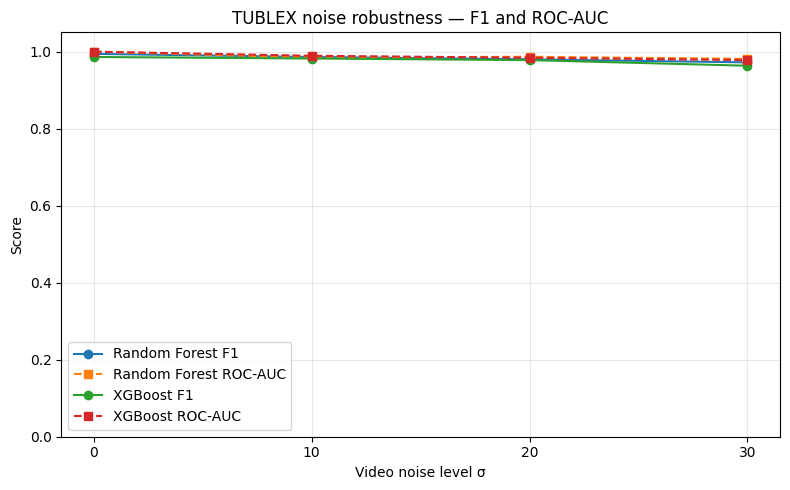

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/noise_robustness_f1_roc_auc.png


In [21]:
# ============================================================
# F1 AND ROC-AUC VERSUS NOISE LEVEL
# ============================================================

plot_df = display_df.copy()

plt.figure(figsize=(8, 5))

for model_name in ["Random Forest", "XGBoost"]:
    sub = plot_df[plot_df["Model"] == model_name].sort_values("Sigma")

    plt.plot(
        sub["Sigma"],
        sub["F1"],
        marker="o",
        label=f"{model_name} F1",
    )

    plt.plot(
        sub["Sigma"],
        sub["ROC-AUC"],
        marker="s",
        linestyle="--",
        label=f"{model_name} ROC-AUC",
    )

plt.xlabel("Video noise level σ")
plt.ylabel("Score")
plt.title("TUBLEX noise robustness — F1 and ROC-AUC")
plt.ylim(0.0, 1.05)
plt.xticks([0, 10, 20, 30])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = FIGURE_DIR / "noise_robustness_f1_roc_auc.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


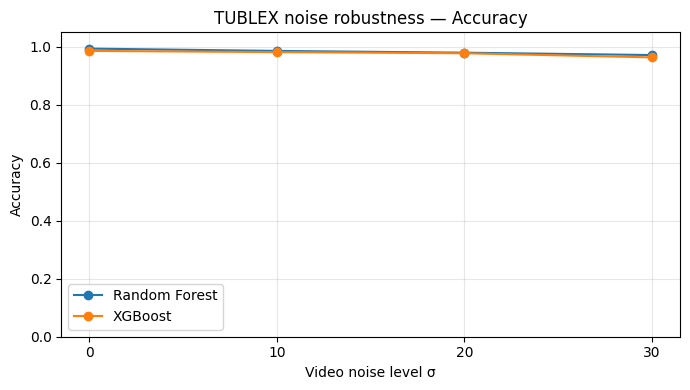

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/noise_robustness_accuracy.png


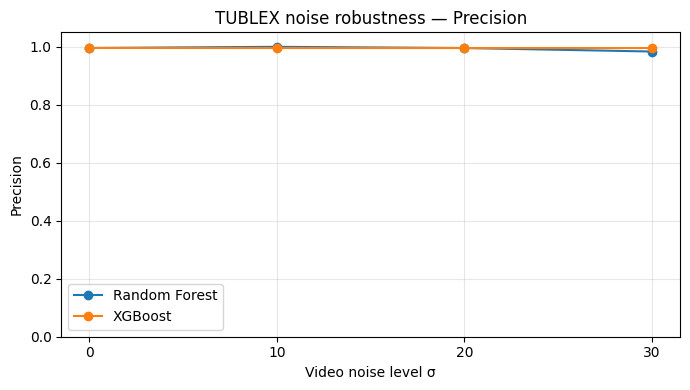

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/noise_robustness_precision.png


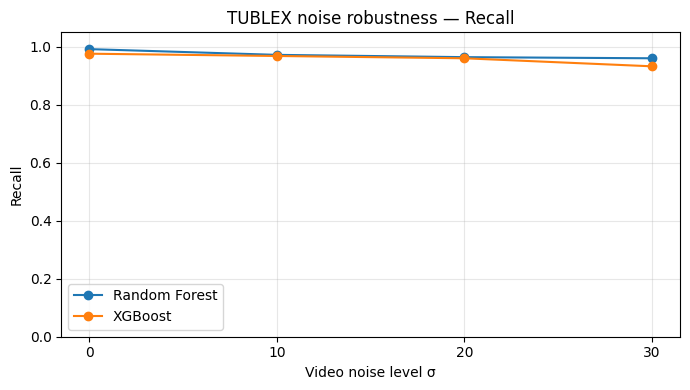

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/noise_robustness_recall.png


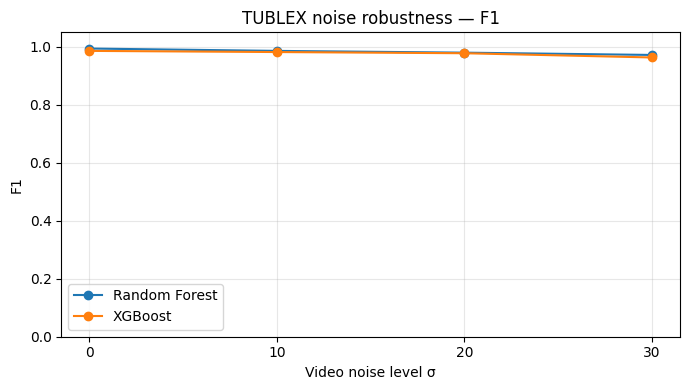

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/noise_robustness_f1.png


In [22]:
# ============================================================
# MAIN METRICS VERSUS NOISE LEVEL
# ============================================================

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))

    for model_name in ["Random Forest", "XGBoost"]:
        sub = display_df[display_df["Model"] == model_name].sort_values("Sigma")

        plt.plot(
            sub["Sigma"],
            sub[metric],
            marker="o",
            label=model_name,
        )

    plt.xlabel("Video noise level σ")
    plt.ylabel(metric)
    plt.title(f"TUBLEX noise robustness — {metric}")
    plt.ylim(0.0, 1.05)
    plt.xticks([0, 10, 20, 30])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    fig_path = FIGURE_DIR / f"noise_robustness_{metric.lower().replace('-', '_')}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


,Condition,Sigma,N Windows,Zero Detection Windows,Zero Detection Rate
0,Clean σ=0,0,495,0,0.0000
1,Noise σ=10,10,495,22,0.0444
2,Noise σ=20,20,495,12,0.0242
3,Noise σ=30,30,495,0,0.0000


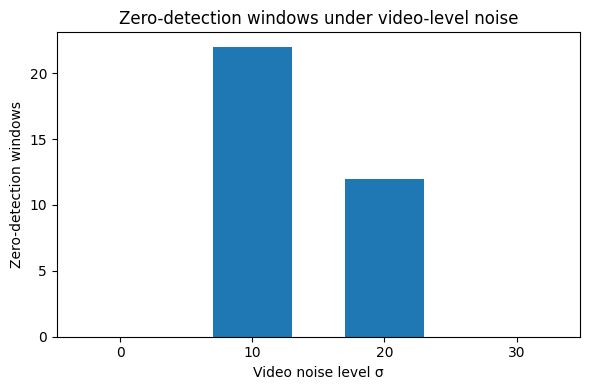

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/tables/zero_detection_summary.csv
Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/zero_detection_windows.png


In [23]:
# ============================================================
# ZERO-DETECTION WINDOW SUMMARY
# ============================================================

zero_summary = []

for sigma_value, (condition_name, dataset) in datasets.items():
    zero_count = int((dataset["max_bubble_count"] == 0).sum())
    zero_summary.append({
        "Condition": condition_name,
        "Sigma": sigma_value,
        "N Windows": len(dataset),
        "Zero Detection Windows": zero_count,
        "Zero Detection Rate": zero_count / len(dataset),
    })

zero_df = pd.DataFrame(zero_summary)
zero_df["Zero Detection Rate"] = zero_df["Zero Detection Rate"].round(4)

zero_path = TABLE_DIR / "zero_detection_summary.csv"
zero_df.to_csv(zero_path, index=False)

display(zero_df)

plt.figure(figsize=(6, 4))
plt.bar(zero_df["Sigma"], zero_df["Zero Detection Windows"], width=6)

plt.xlabel("Video noise level σ")
plt.ylabel("Zero-detection windows")
plt.title("Zero-detection windows under video-level noise")
plt.xticks([0, 10, 20, 30])
plt.tight_layout()

fig_path = FIGURE_DIR / "zero_detection_windows.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", zero_path)
print("Saved:", fig_path)


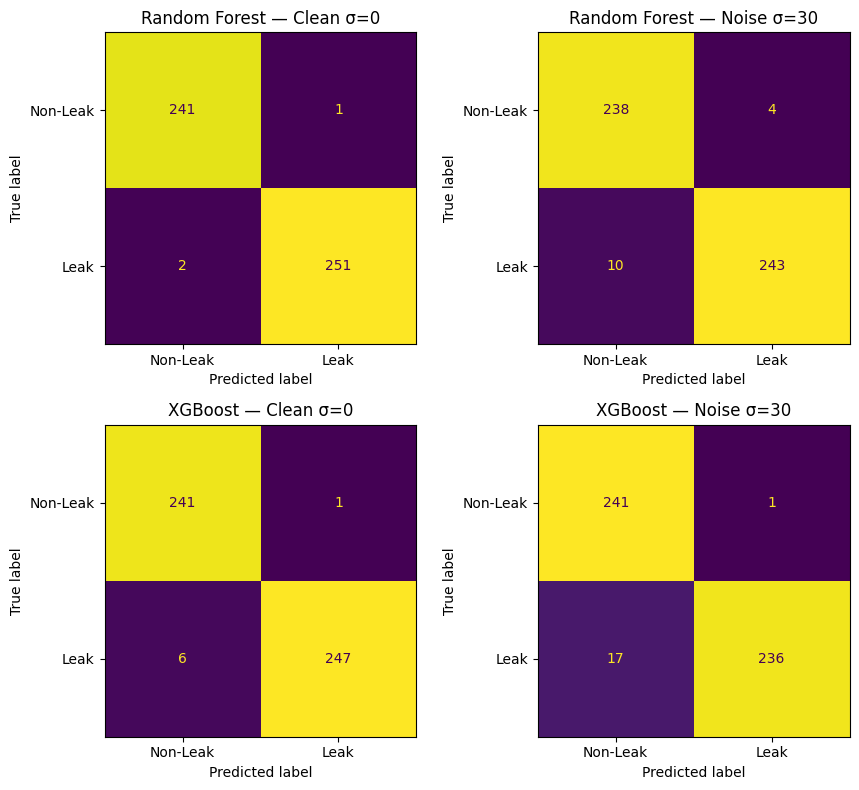

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/figures/confusion_matrices_clean_vs_sigma30.png


In [24]:
# ============================================================
# CONFUSION MATRICES CLEAN VS SIGMA 30
# ============================================================

def get_predictions_for(model, dataset, model_metadata):
    feature_columns = model_metadata["feature_columns"]
    threshold = model_metadata.get("decision_threshold", 0.5)
    positive_class = model_metadata.get("positive_class", 1)

    X = dataset[feature_columns]
    y = dataset["label"].astype(int)
    positive_idx = positive_class_index(model, positive_class=positive_class)
    prob = model.predict_proba(X)[:, positive_idx]
    pred = (prob >= threshold).astype(int)
    return y, pred

comparison_cases = [
    ("Random Forest", rf_model, rf_metadata, "Clean σ=0", clean_test),
    ("Random Forest", rf_model, rf_metadata, "Noise σ=30", noise_datasets[30]),
    ("XGBoost", xgb_model, xgb_metadata, "Clean σ=0", clean_test),
    ("XGBoost", xgb_model, xgb_metadata, "Noise σ=30", noise_datasets[30]),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))

for ax, (model_name, model, model_metadata, condition_name, dataset) in zip(axes.ravel(), comparison_cases):
    y_true, pred = get_predictions_for(model, dataset, model_metadata)
    cm = confusion_matrix(y_true, pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Leak", "Leak"],
    ).plot(values_format="d", ax=ax, colorbar=False)

    ax.set_title(f"{model_name} — {condition_name}")

plt.tight_layout()

fig_path = FIGURE_DIR / "confusion_matrices_clean_vs_sigma30.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [27]:
# ============================================================
# PERFORMANCE DROP FROM CLEAN BASELINE
# ============================================================

drop_rows = []

for model_name in ["Random Forest", "XGBoost"]:
    clean_row = display_df[
        (display_df["Model"] == model_name)
        & (display_df["Sigma"] == 0)
    ].iloc[0]

    for sigma_value in [10, 20, 30]:
        noisy_row = display_df[
            (display_df["Model"] == model_name)
            & (display_df["Sigma"] == sigma_value)
        ].iloc[0]

        drop_rows.append({
            "Model": model_name,
            "Sigma": sigma_value,
            "Accuracy Drop": clean_row["Accuracy"] - noisy_row["Accuracy"],
            "F1 Drop": clean_row["F1"] - noisy_row["F1"],
            "ROC-AUC Drop": clean_row["ROC-AUC"] - noisy_row["ROC-AUC"],
            "PR-AUC Drop": clean_row["PR-AUC"] - noisy_row["PR-AUC"],
        })

drop_df = pd.DataFrame(drop_rows)
drop_df = drop_df.round(4)

drop_path = TABLE_DIR / "performance_drop_from_clean.csv"
drop_df.to_csv(drop_path, index=False)

display(drop_df)

print("Saved:", drop_path)


,Model,Sigma,Accuracy Drop,F1 Drop,ROC-AUC Drop,PR-AUC Drop
0,Random Forest,10,0.0080,0.0081,0.0151,0.0099
1,Random Forest,20,0.0141,0.0142,0.0134,0.0090
2,Random Forest,30,0.0222,0.0221,0.0188,0.0120
3,XGBoost,10,0.0041,0.0040,0.0106,0.0064
4,XGBoost,20,0.0081,0.0081,0.0158,0.0092
5,XGBoost,30,0.0223,0.0227,0.0219,0.0124


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/noise_robustness/tables/performance_drop_from_clean.csv


## Conclusion

This notebook evaluates the saved Random Forest and XGBoost models under video-level noise degradation using the same official 17-video hold-out split as the clean test evaluation.

Because noise is applied before TUBLEX feature extraction, this experiment measures robustness of the full visual descriptor pipeline rather than only the classifier response to artificial feature perturbation. Zero-detection windows are retained because they represent real extraction failures under degraded visual conditions.

The resulting tables and figures compare Random Forest and XGBoost under increasing video noise levels and support the robustness analysis used in the TUBLEX repository.
